In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb

import kdar_functions as kdar
import general_functions as utils

import importlib



In [2]:
importlib.reload(kdar)
importlib.reload(utils)

<module 'general_functions' from '/Users/bbogart/Documents/analysisCode/kdar_bdt/general_functions.py'>

In [3]:
single_run = False

more_gibuu = True


In [12]:

model_hiE = xgb.Booster({'nthread': 4})  # init model
model_hiE.load_model('model_hiE_3.json')  # load data

model_lowE = xgb.Booster({'nthread': 4})  # init model
model_lowE.load_model('model_lowE_3.json')  # load data

model_hiE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_hiE_genie_only.load_model('model_hiE_genie_only_1.json')  # load data

model_lowE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_lowE_genie_only.load_model('model_lowE_genie_only_1.json')  # load data

lowE_cut = 0.8
hiE_cut = 0.9

bdt_query = f"kdar_score_hiE<{hiE_cut} and kdar_score_lowE<{hiE_cut}"


In [5]:
def plot_eff(truth_vars,sig_query,sel_query,bins_list,xlabels=[],ylabel="Efficiency",adjusty=False):    
    

    
    sig_test_df = kdar_overlay_df.query(sig_query).copy()
    sig_sel_test_df = kdar_overlay_df.query(sig_query).query(sel_query).copy()
    
    sig_nuwro_df = nuwro_df.query(sig_query).copy()
    sig_sel_nuwro_df = nuwro_df.query(sig_query).query(sel_query).copy()
    
    sig_gibuu_df = gibuu_df.query(sig_query).copy()
    sig_sel_gibuu_df = gibuu_df.query(sig_query).query(sel_query).copy()
    
    presel_eff = []
    nuwro_presel_eff = []
    gibuu_presel_eff = []
    
    for i in range(len(truth_vars)):
        
        var = truth_vars[i]
        bins = bins_list[i]
        test_sig, x = np.histogram( np.clip(sig_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df['net_weight'].to_numpy())
        test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df['net_weight'].to_numpy())
        nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df['net_weight'].to_numpy())
        nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df['net_weight'].to_numpy())
        gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df['net_weight'].to_numpy())
        gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df['net_weight'].to_numpy())
        if var == "true_angle_P_deg":
            test_sig, x = np.histogram( np.clip(sig_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            
        test_eff = []
        test_err = np.nan_to_num(utils.wilson_err(test_sig_sel, test_sig),nan=0)
        
        nuwro_eff = []
        nuwro_err = np.nan_to_num(utils.wilson_err(nuwro_sig_sel, nuwro_sig),nan=0)
        
        gibuu_eff = []
        temp_sig_query = sig_query
        if var == "true_angle_P_deg":
            temp_sig_query+=" and truth_prim_p_energy>0"
        gibuu_err = np.nan_to_num(kdar.bootstrap_err(gibuu_df, var, bins, temp_sig_query, sel_query, n_replicates=300, confidence_level=68,weight_var="net_weight"),nan=0)
        
        err_truth = utils.get_x_err_Enu(utils.get_bin_centers(bins),bins)
    
        for b in range(len(bins)-1):
            if test_sig[b]==0: test_eff.append(np.nan)
            else: test_eff.append(test_sig_sel[b]/test_sig[b])
            if nuwro_sig[b]==0: nuwro_eff.append(np.nan)
            else: nuwro_eff.append(nuwro_sig_sel[b]/nuwro_sig[b])
            if gibuu_sig[b]==0: gibuu_eff.append(np.nan)
            else: gibuu_eff.append(gibuu_sig_sel[b]/gibuu_sig[b])

        test_sig = np.nan_to_num(test_sig,nan=0)
        nuwro_eff = np.nan_to_num(nuwro_eff,nan=0)
        gibuu_eff = np.nan_to_num(gibuu_eff,nan=0)
                
        plt.figure()
        plt.errorbar(utils.get_bin_centers(bins),test_eff,xerr=err_truth,yerr=test_err,label='GENIE', ms=10, fmt='o',lw=4.5,color='black')
        plt.errorbar(utils.get_bin_centers(bins),nuwro_eff,xerr=err_truth,yerr=nuwro_err,label='NuWro', ms=10, fmt='<',lw=3.5,color='red')
        plt.errorbar(utils.get_bin_centers(bins),gibuu_eff,xerr=err_truth,yerr=gibuu_err,label='GiBUU', ms=10, fmt='>',lw=2.5,color='dodgerblue')
        #plt.errorbar(utils.get_bin_centers(bins),test_eff,xerr=err_truth,yerr=test_err,label='GENIE', ms=0, fmt='o',lw=4.5,color='black')
        #plt.errorbar(utils.get_bin_centers(bins),nuwro_eff,xerr=err_truth,yerr=nuwro_err,label='NuWro', ms=0, fmt='o',lw=3.5,color='red')
        #plt.errorbar(utils.get_bin_centers(bins),gibuu_eff,xerr=err_truth,yerr=gibuu_err,label='GiBUU', ms=0, fmt='o',lw=2.5,color='dodgerblue')
        plt.ylim(0,1.05)
        if adjusty!=False: plt.ylim(0,adjusty)
        plt.xlabel(xlabels[i])
        plt.ylabel(ylabel)
        plt.legend()
        plt.show()
    
        


In [6]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
kdar_overlay_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

kdar_overlay_df["horncur"] = ["RHC" for i in range(kdar_overlay_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
    kdar_overlay_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    kdar_overlay_df_2["horncur"] = ["FHC" for i in range(kdar_overlay_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    kdar_overlay_df = pd.concat([kdar_overlay_df, kdar_overlay_df_2], sort=False)

kdar_overlay_df = kdar.apply_goodruns(kdar_overlay_df)

kdar_overlay_df["net_weight"] = kdar_overlay_df["weight_cv"].to_numpy()*kdar_overlay_df["weight_spline"].to_numpy()
print("All events",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["rse_num"] = (kdar_overlay_df["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df["event"].to_numpy())
kdar_overlay_df = kdar_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

#kdar_overlay_df = kdar_overlay_df.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["isEXT"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["isDirt"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["POTscaled"] = [1 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["is_KDAR"] = [1 for i in range(kdar_overlay_df.shape[0])]

All events 90014 91586.64
Duplicates Dropped 90014 91586.64
In FV 90014 91586.64


In [7]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
nuwro_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

nuwro_df["horncur"] = ["RHC" for i in range(nuwro_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    nuwro_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    nuwro_df_2["horncur"] = ["FHC" for i in range(nuwro_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    nuwro_df = pd.concat([nuwro_df, nuwro_df_2], sort=False)

nuwro_df = kdar.apply_goodruns(nuwro_df)

nuwro_df["net_weight"] = [1 for i in range(nuwro_df.shape[0])]
print("All events",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["rse_num"] = (nuwro_df["run"].to_numpy() * 100_000_000_000
                         + nuwro_df["subrun"].to_numpy() * 1_000_000
                         + nuwro_df["event"].to_numpy())
nuwro_df = nuwro_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

#nuwro_df = nuwro_df.query("truth_vtxInside==1")
print("In FV",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["isEXT"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["isDirt"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["WC_file"] = ["numi_kdar_overlay" for i in range(nuwro_df.shape[0])]
nuwro_df["POTscaled"] = [1 for i in range(nuwro_df.shape[0])]
nuwro_df["is_KDAR"] = [1 for i in range(nuwro_df.shape[0])]


All events 91017 91017
Duplicates Dropped 91017 91017
In FV 91017 91017


In [8]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
gibuu_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

gibuu_df["horncur"] = ["RHC" for i in range(gibuu_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    gibuu_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    gibuu_df_2["horncur"] = ["FHC" for i in range(gibuu_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine
    
    gibuu_df = pd.concat([gibuu_df, gibuu_df_2], sort=False)

if more_gibuu:
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run4b_train_add.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    gibuu_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)
    
    gibuu_df_2["horncur"] = ["RHC" for i in range(gibuu_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    gibuu_df = pd.concat([gibuu_df, gibuu_df_2], sort=False)

gibuu_df = kdar.apply_goodruns(gibuu_df)

gibuu_df["net_weight"] = gibuu_df["truth_nuTime"].to_numpy()
print("All events",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["rse_num"] = (gibuu_df["run"].to_numpy() * 100_000_000_000
                         + gibuu_df["subrun"].to_numpy() * 1_000_000
                         + gibuu_df["event"].to_numpy())
gibuu_df = gibuu_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

#gibuu_df = gibuu_df.query("truth_vtxInside==1")
print("In FV",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["isEXT"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["isDirt"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["WC_file"] = ["numi_kdar_overlay" for i in range(gibuu_df.shape[0])]
gibuu_df["POTscaled"] = [1 for i in range(gibuu_df.shape[0])]
gibuu_df["is_KDAR"] = [1 for i in range(gibuu_df.shape[0])]


All events 203065 0.0023433245
Duplicates Dropped 203065 0.0023433245
In FV 203065 0.0023433245


In [9]:

kdar_overlay_df = kdar.add_ntrue_nu_angle(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_muon_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_ssm_info(kdar_overlay_df)

nuwro_df = kdar.add_ntrue_nu_angle(nuwro_df)
nuwro_df = kdar.add_truth_muon_info(nuwro_df)
nuwro_df = kdar.add_truth_proton_info(nuwro_df)
nuwro_df = kdar.add_truth_ssm_info(nuwro_df)

gibuu_df = kdar.add_ntrue_nu_angle(gibuu_df)
gibuu_df = kdar.add_truth_muon_info(gibuu_df)
gibuu_df = kdar.add_truth_proton_info(gibuu_df)
gibuu_df = kdar.add_truth_ssm_info(gibuu_df)


 34%|███████████▎                     | 69363/203065 [00:01<00:02, 62788.60it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1836: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cos)
100%|████████████████████████████████| 203065/203065 [00:03<00:00, 61644.67it/s]


In [10]:

kdar_overlay_df = kdar.add_ssm_kine_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_reco_proton_muon(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df)

nuwro_df = kdar.add_ssm_kine_info(nuwro_df)
nuwro_df = kdar.add_ssm_reco_proton_info(nuwro_df)
nuwro_df = kdar.add_reco_proton_muon(nuwro_df)
nuwro_df = kdar.add_ssm_reco_dirt_vars(nuwro_df)

gibuu_df = kdar.add_ssm_kine_info(gibuu_df)
gibuu_df = kdar.add_ssm_reco_proton_info(gibuu_df)
gibuu_df = kdar.add_reco_proton_muon(gibuu_df)
gibuu_df = kdar.add_ssm_reco_dirt_vars(gibuu_df)


100%|█████████████████████████████████| 90014/90014 [00:00<00:00, 648260.18it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2050: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_cosMuP"] = cosMuP
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2051: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_angle_MuP"] = angle_MuP
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:2052: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

In [13]:

kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

nuwro_df = kdar.add_bdt_scores(nuwro_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
nuwro_df = kdar.add_bdt_scores(nuwro_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

gibuu_df = kdar.add_bdt_scores(gibuu_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
gibuu_df = kdar.add_bdt_scores(gibuu_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")


100%|███████████████████████████████| 203065/203065 [00:00<00:00, 990977.41it/s]


In [33]:

bm_query = "truth_energyInside*0.1>match_completeness_energy or match_energy>500"
not_bm_query = "not("+bm_query+")"


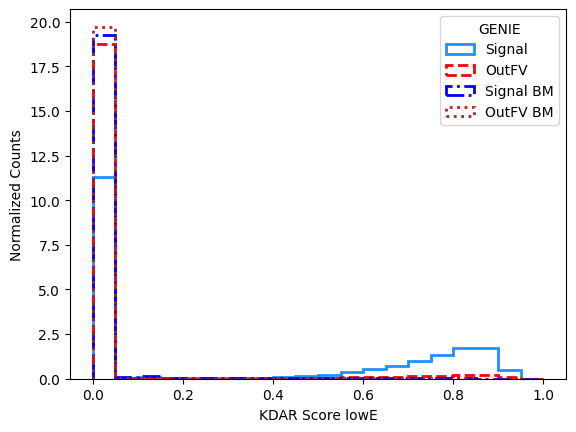

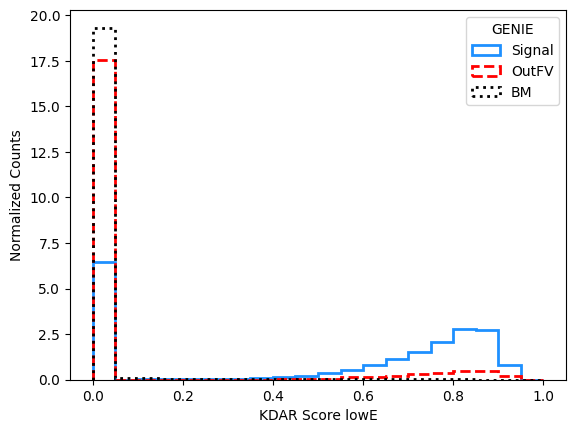

In [36]:

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


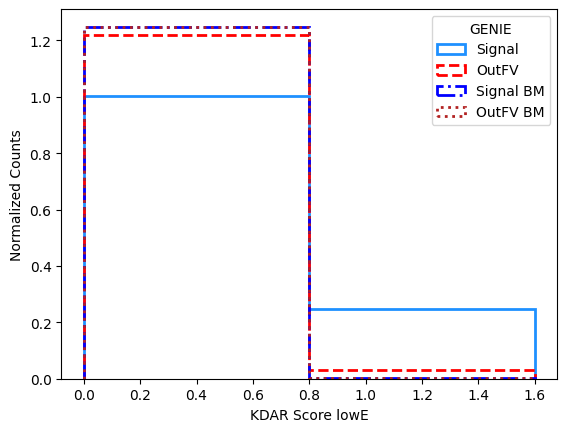

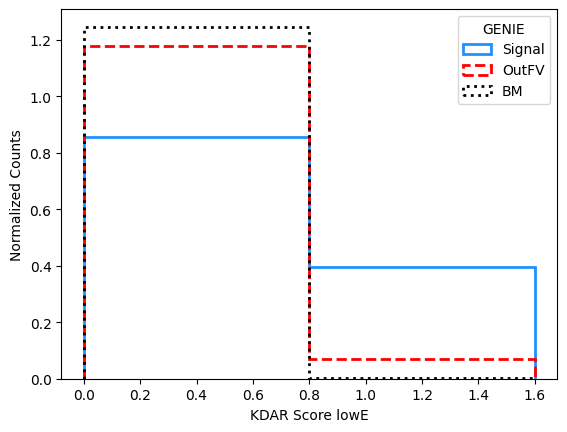

In [37]:

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


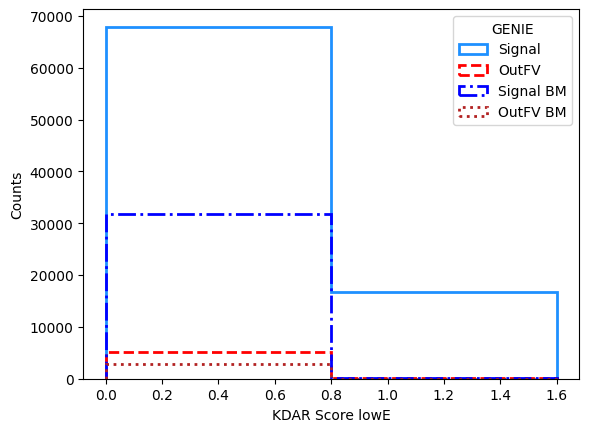

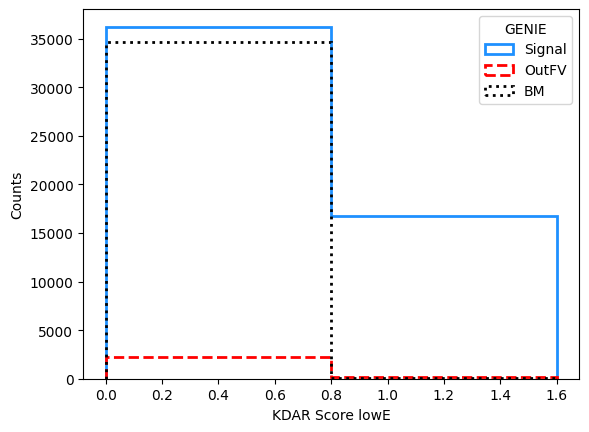

In [38]:

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Counts")
plt.show()

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Counts")
plt.show()


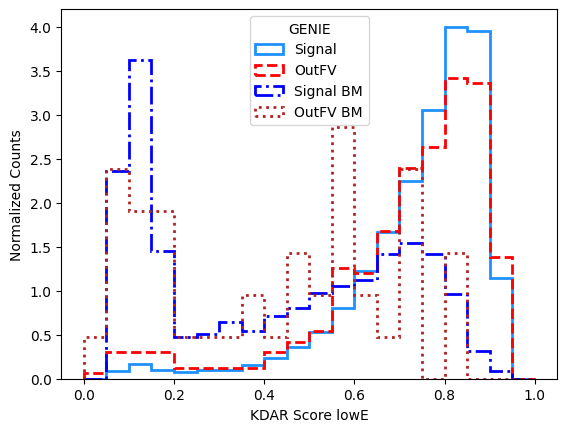

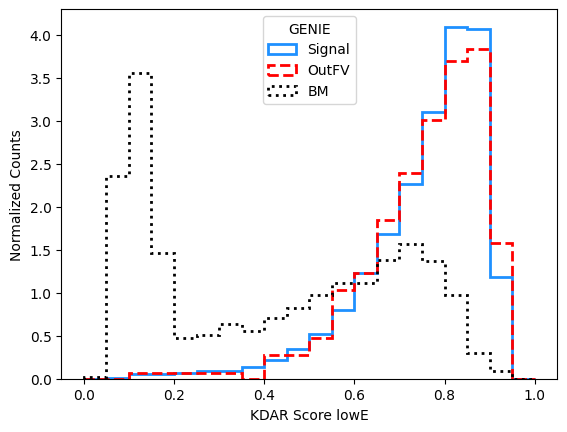

In [49]:

plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query(bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()



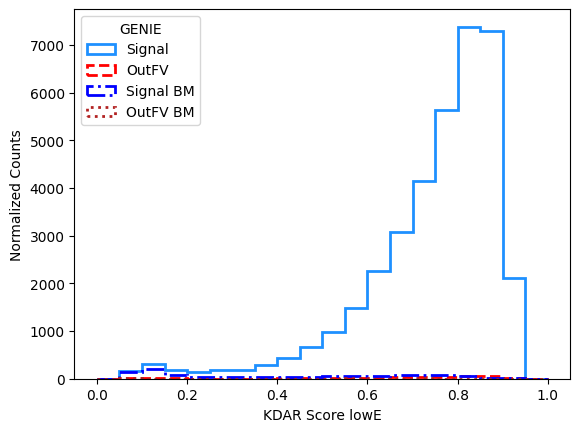

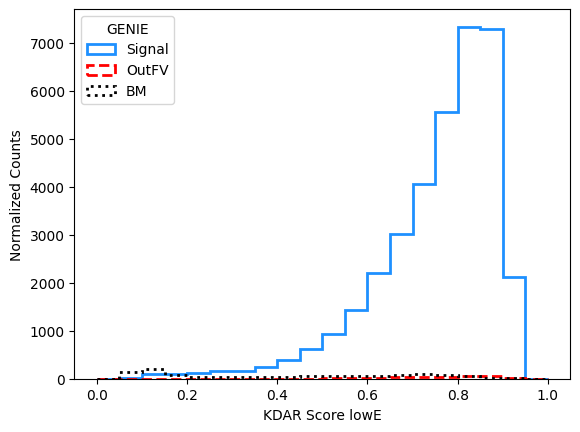

In [48]:
plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(kdar_overlay_df.query(bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

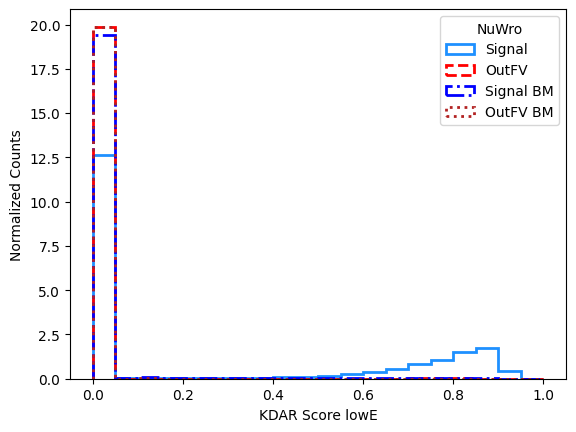

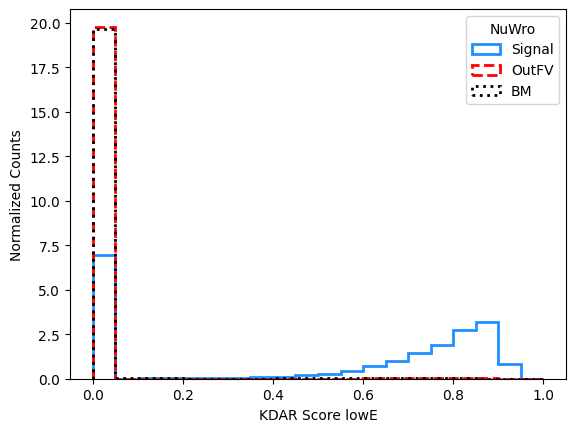

In [43]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


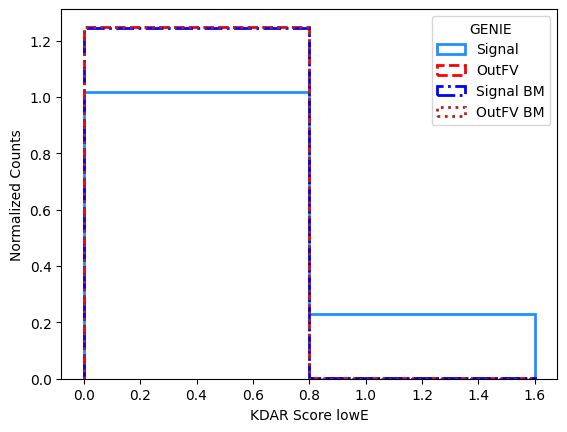

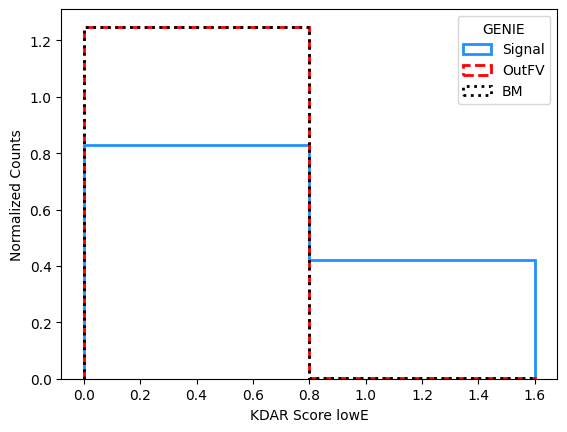

In [44]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


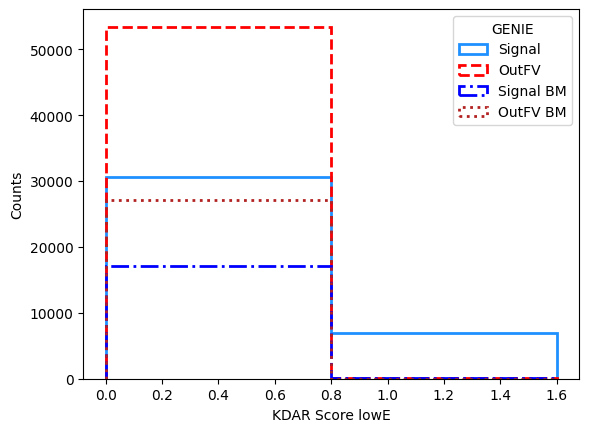

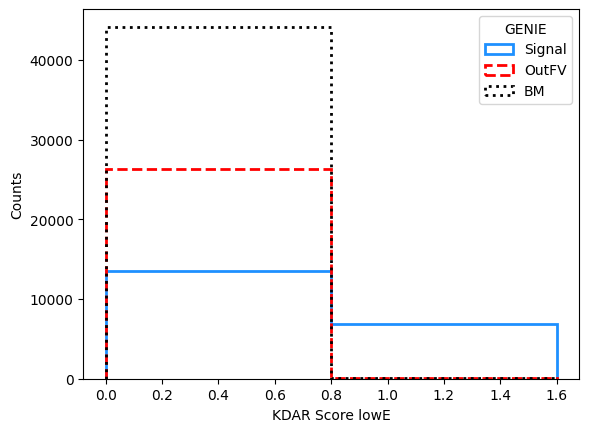

In [45]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='GENIE')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Counts")
plt.show()


In [46]:
y,x = np.histogram(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6))
print(y)
y,x =np.histogram(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6))
print(y)
y,x =np.histogram(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),0,1),bins=2,range=(0,1.6))
print(y)


[13544  6892]
[26273    76]
[44178    54]


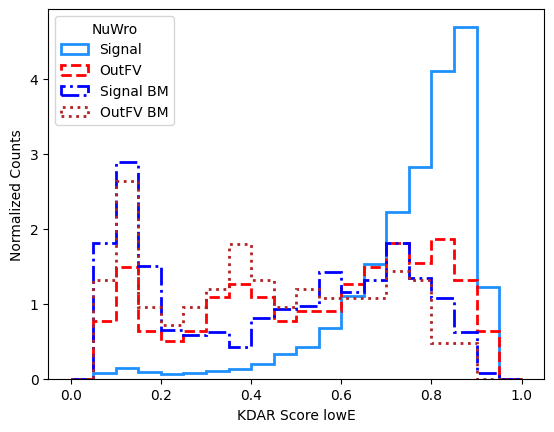

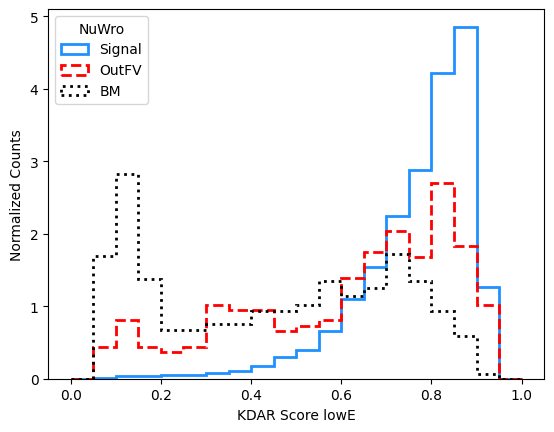

In [47]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()



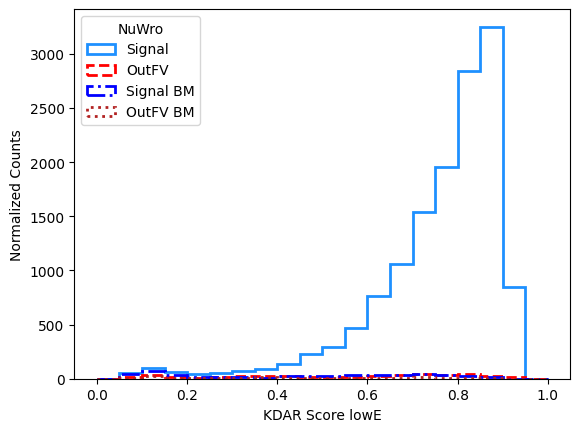

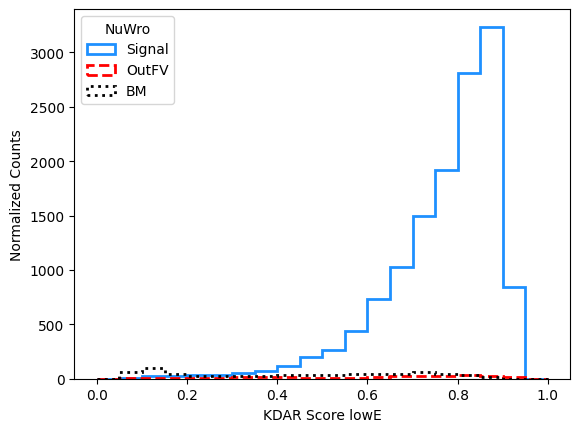

In [50]:
plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_lowE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score lowE")
plt.ylabel("Normalized Counts")
plt.show()

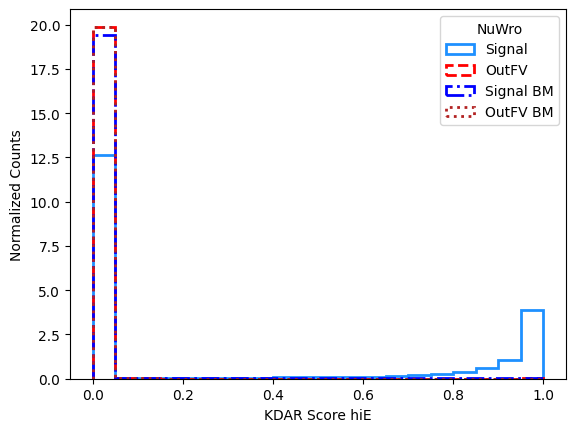

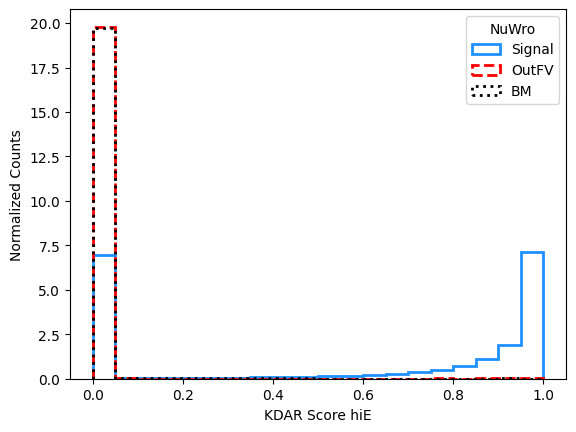

In [51]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()


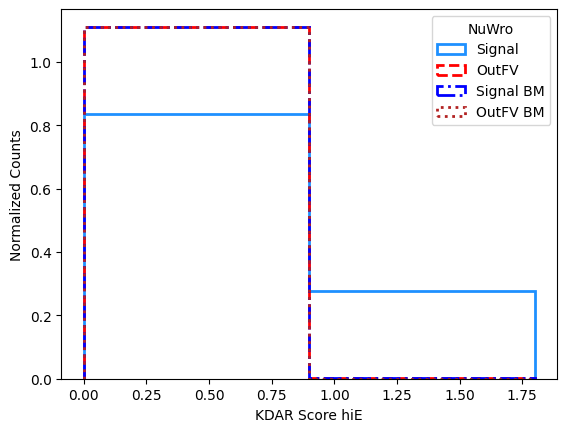

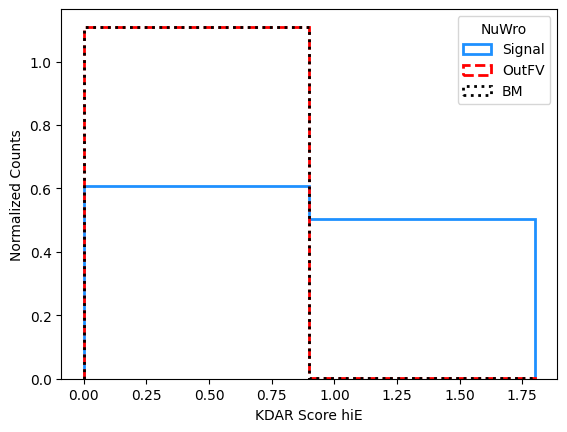

In [52]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()


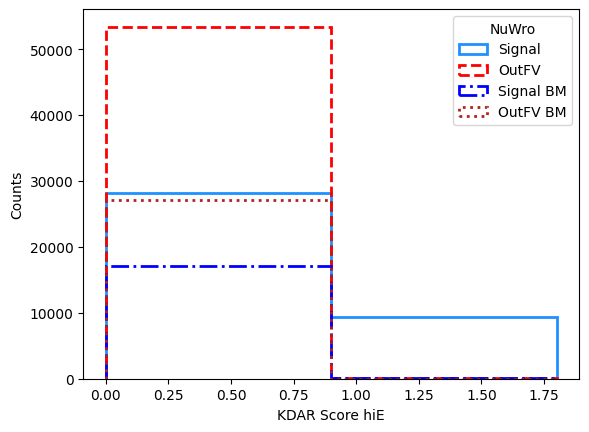

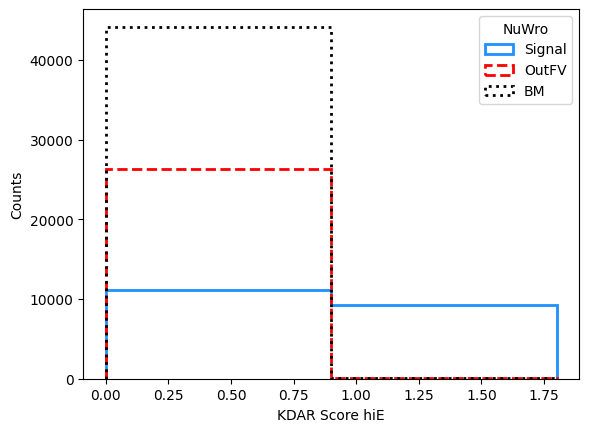

In [53]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.8),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Counts")
plt.show()


In [54]:
y,x = np.histogram(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.9))
print(y)
y,x =np.histogram(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.9))
print(y)
y,x =np.histogram(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),0,1),bins=2,range=(0,1.9))
print(y)

[13148  7288]
[26285    64]
[44211    21]


In [55]:

print(nuwro_df.query("truth_vtxInside==1").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(nuwro_df.query("truth_vtxInside==0").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(nuwro_df.query(bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])


6215
56
23


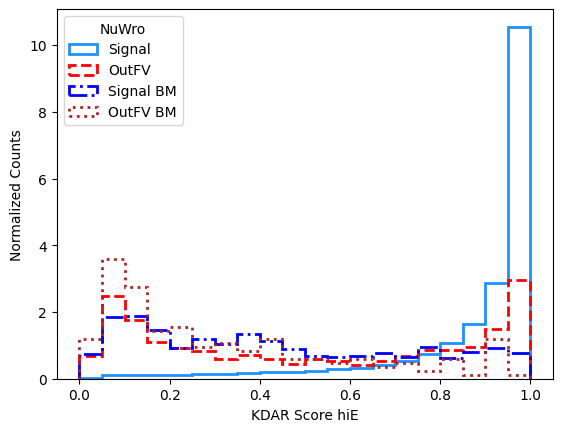

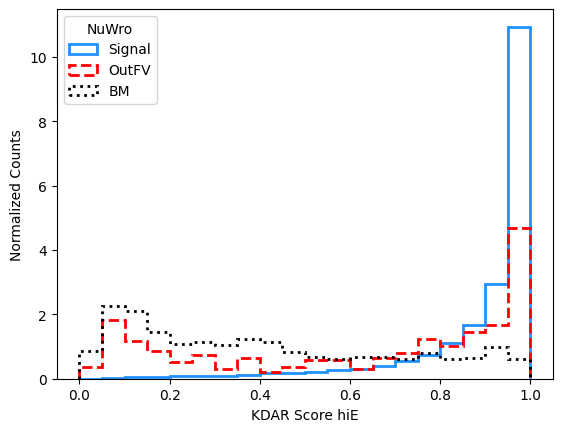

In [56]:

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()



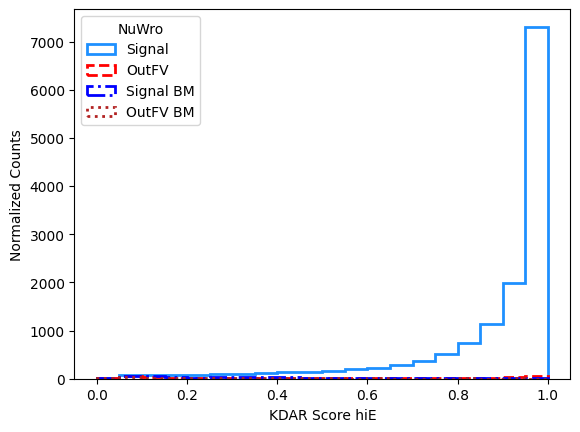

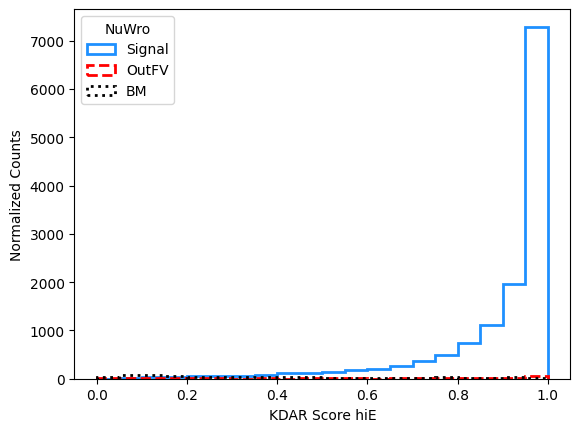

In [57]:
plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-.',density=False,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)")["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()


plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='-',density=False,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls='--',density=False,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query)["kdar_score_hiE"].to_numpy(),-999,1),bins=20,range=(0,1),
         histtype='step',lw=2,ls=':',density=False,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("KDAR Score hiE")
plt.ylabel("Normalized Counts")
plt.show()

In [67]:
sidband_query = "numu_score>0.9 and match_isFC==1 and not(kdar_score_lowE>0.8 and kdar_score_hiE>0.9 and +"+kdar.presel_query+")"

far_sidband_query = "numu_score>0.9 and match_isFC==1 and not(kdar_score_lowE>0.6 and kdar_score_hiE>0.8 and +"+kdar.presel_query+")"



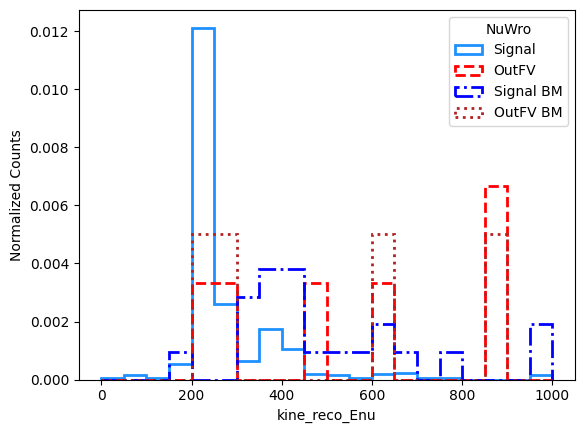

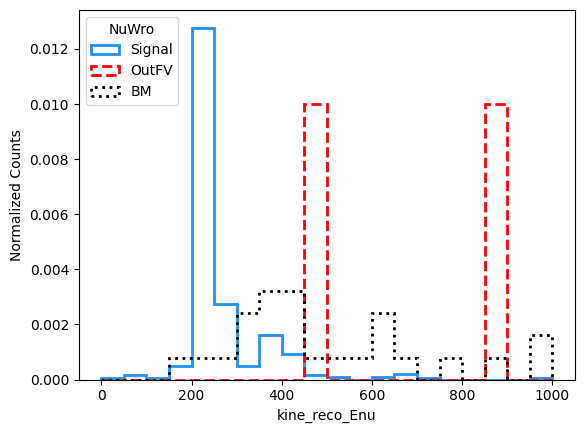

In [61]:


plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)").query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls='-.',density=True,label="Signal BM",color='blue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0 and (truth_energyInside*0.1>match_completeness_energy or match_energy>500)").query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls=':',density=True,label="OutFV BM",color='firebrick')
plt.legend(title='NuWro')
plt.xlabel("kine_reco_Enu")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==1").query(not_bm_query).query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls='-',density=True,label="Signal",color='dodgerblue')
plt.hist(np.clip(nuwro_df.query("truth_vtxInside==0").query(not_bm_query).query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls='--',density=True,label="OutFV",color='red')
plt.hist(np.clip(nuwro_df.query(bm_query).query(sidband_query)["kine_reco_Enu"].to_numpy(),0,1000),bins=20,range=(0,1000),
         histtype='step',lw=2,ls=':',density=True,label="BM",color='black')
plt.legend(title='NuWro')
plt.xlabel("kine_reco_Enu")
plt.ylabel("Normalized Counts")
plt.show()

In [63]:
print(nuwro_df.query("truth_vtxInside==1").query(not_bm_query).query(sidband_query).shape[0])
print(nuwro_df.query("truth_vtxInside==0").query(not_bm_query).query(sidband_query).shape[0])
print(nuwro_df.query(bm_query).query(sidband_query).shape[0])

393
2
25


In [68]:
print(nuwro_df.query("truth_vtxInside==1").query(not_bm_query).query(far_sidband_query).shape[0])
print(nuwro_df.query("truth_vtxInside==0").query(not_bm_query).query(far_sidband_query).shape[0])
print(nuwro_df.query(bm_query).query(far_sidband_query).shape[0])

156
2
23


In [69]:
print(nuwro_df.query("truth_vtxInside==1").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(nuwro_df.query("truth_vtxInside==0").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(nuwro_df.query(bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])

6215
56
23


In [74]:
393/6215

0.06323411102172165

In [76]:
156/6215

0.0251005631536605

In [70]:
print(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query).query(sidband_query).shape[0])
print(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query).query(sidband_query).shape[0])
print(kdar_overlay_df.query(bm_query).query(sidband_query).shape[0])

1485
0
52


In [71]:
print(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query).query(far_sidband_query).shape[0])
print(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query).query(far_sidband_query).shape[0])
print(kdar_overlay_df.query(bm_query).query(far_sidband_query).shape[0])

673
0
49


In [72]:
print(kdar_overlay_df.query("truth_vtxInside==1").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(kdar_overlay_df.query("truth_vtxInside==0").query(not_bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])
print(kdar_overlay_df.query(bm_query).query("kdar_score_hiE>0.9").query("kdar_score_lowE>0.8").shape[0])

15549
111
36


In [73]:
1485/15549

0.09550453405363689

In [75]:
673/15549

0.04328252620747315